In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_INTERIM)
print("Outputs directory:", OUTPUTS_DIR)

Project root: /Users/chelsearose/Documents/GitHub/county-obesity-prediction
Data directory: /Users/chelsearose/Documents/GitHub/county-obesity-prediction/data/interim
Outputs directory: /Users/chelsearose/Documents/GitHub/county-obesity-prediction/outputs


In [2]:
modeling_data = pd.read_csv(
    DATA_INTERIM / "modeling_data.csv",
    dtype={"FIPS": "string"}
)

predictor_columns = [
    "PCT_LACCESS_POP19",
    "PCT_LACCESS_LOWI19",
    "GROCPTH20",
    "CONVSPTH20",
    "FFRPTH20",
    "FSRPTH20",
    "MEDHHINC21",
    "POVRATE21",
    "CHILDPOVRATE21",
    "DEEPPOVRATE21",
    "PC_SNAPBEN22",
    "PCT_65OLDER20",
    "PCT_18YOUNGER20",
    "PCT_NHWHITE20",
    "PCT_NHBLACK20",
    "PCT_HISP20",
    "PCT_NHASIAN20",
    "RECFACPTH20"
]

target_column = "OBESITY_AdjPrev"

X = modeling_data[predictor_columns].copy()
y = modeling_data[target_column].copy()

print("Dataset shape:", modeling_data.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of candidate predictors:", len(predictor_columns))
print("Missing target values:", y.isna().sum())
print("Unique FIPS:", modeling_data["FIPS"].nunique())

Dataset shape: (3135, 22)
X shape: (3135, 18)
y shape: (3135,)
Number of candidate predictors: 18
Missing target values: 0
Unique FIPS: 3135


In [3]:
class ThesisPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, missing_threshold=20.0, correlation_threshold=0.80):
        self.missing_threshold = missing_threshold
        self.correlation_threshold = correlation_threshold

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()

        # 1. Assess missingness using training data
        self.missingness_percent_ = X.isna().mean() * 100

        self.excluded_missing_ = self.missingness_percent_[
            self.missingness_percent_ > self.missing_threshold
        ].index.tolist()

        self.after_missing_columns_ = [
            col for col in X.columns
            if col not in self.excluded_missing_
        ]

        # 2. Fit median imputer using training data
        self.imputer_ = SimpleImputer(strategy="median")
        self.imputer_.fit(X[self.after_missing_columns_])

        X_imputed = pd.DataFrame(
            self.imputer_.transform(X[self.after_missing_columns_]),
            columns=self.after_missing_columns_,
            index=X.index
        )

        # 3. Pearson correlation after missing-value treatment
        corr_matrix = X_imputed.corr()

        self.high_corr_pairs_ = []

        for i in range(len(corr_matrix.columns)):
            for j in range(i + 1, len(corr_matrix.columns)):
                corr_value = corr_matrix.iloc[i, j]

                if abs(corr_value) >= self.correlation_threshold:
                    self.high_corr_pairs_.append(
                        (
                            corr_matrix.columns[i],
                            corr_matrix.columns[j],
                            corr_value
                        )
                    )

        # Predefined thesis correlation decisions
        self.excluded_correlation_ = []

        predefined_decisions = [
            ("POVRATE21", "CHILDPOVRATE21", "CHILDPOVRATE21"),
            (
                "PCT_LACCESS_POP19",
                "PCT_LACCESS_LOWI19",
                "PCT_LACCESS_POP19"
            )
        ]

        high_corr_pair_names = {
            frozenset([col1, col2])
            for col1, col2, _ in self.high_corr_pairs_
        }

        for col1, col2, remove_col in predefined_decisions:
            if frozenset([col1, col2]) in high_corr_pair_names:
                self.excluded_correlation_.append(remove_col)

        self.retained_columns_ = [
            col for col in self.after_missing_columns_
            if col not in self.excluded_correlation_
        ]

        # 4. Calculate IQR thresholds for documentation
        self.iqr_summary_ = {}

        for col in self.retained_columns_:
            q1 = X_imputed[col].quantile(0.25)
            q3 = X_imputed[col].quantile(0.75)
            iqr = q3 - q1

            self.iqr_summary_[col] = {
                "Q1": q1,
                "Q3": q3,
                "IQR": iqr,
                "Lower_Bound": q1 - 1.5 * iqr,
                "Upper_Bound": q3 + 1.5 * iqr
            }

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        X_imputed = pd.DataFrame(
            self.imputer_.transform(X[self.after_missing_columns_]),
            columns=self.after_missing_columns_,
            index=X.index
        )

        return X_imputed[self.retained_columns_]

In [4]:
preprocessor = ThesisPreprocessor(
    missing_threshold=20.0,
    correlation_threshold=0.80
)

preprocessor.fit(X)

X_processed = preprocessor.transform(X)

print("Original predictor count:", X.shape[1])
print("Processed predictor count:", X_processed.shape[1])

print("\nExcluded for >20% missingness:")
print(preprocessor.excluded_missing_)

print("\nExcluded for high correlation:")
print(preprocessor.excluded_correlation_)

print("\nRetained predictors:")
for col in preprocessor.retained_columns_:
    print("-", col)

print("\nProcessed shape:", X_processed.shape)
print("Remaining missing values:", X_processed.isna().sum().sum())

Original predictor count: 18
Processed predictor count: 14

Excluded for >20% missingness:
['GROCPTH20', 'RECFACPTH20']

Excluded for high correlation:
['CHILDPOVRATE21', 'PCT_LACCESS_POP19']

Retained predictors:
- PCT_LACCESS_LOWI19
- CONVSPTH20
- FFRPTH20
- FSRPTH20
- MEDHHINC21
- POVRATE21
- DEEPPOVRATE21
- PC_SNAPBEN22
- PCT_65OLDER20
- PCT_18YOUNGER20
- PCT_NHWHITE20
- PCT_NHBLACK20
- PCT_HISP20
- PCT_NHASIAN20

Processed shape: (3135, 14)
Remaining missing values: 0


In [5]:
rf_hyperparameters = pd.read_csv(
    OUTPUTS_DIR / "random_forest" / "rf_best_hyperparameters.csv"
)

xgb_hyperparameters = pd.read_csv(
    OUTPUTS_DIR / "xgboost" / "xgb_best_hyperparameters.csv"
)

print("Random Forest hyperparameters across outer folds:")
display(rf_hyperparameters)

print("\nXGBoost hyperparameters across outer folds:")
display(xgb_hyperparameters)

Random Forest hyperparameters across outer folds:


,fold,n_estimators,max_depth,min_samples_split,inner_CV_RMSE
0,1,100,NaN,2,2.851501
1,2,100,20.0,5,2.917585
2,3,100,20.0,5,2.901227
3,4,100,20.0,5,2.962294
4,5,100,NaN,2,2.940986



XGBoost hyperparameters across outer folds:


,fold,learning_rate,n_estimators,max_depth,subsample,inner_CV_RMSE
0,1,0.05,200,4,0.8,2.782504
1,2,0.05,200,4,0.8,2.838232
2,3,0.05,200,4,0.8,2.826374
3,4,0.05,200,4,0.8,2.899474
4,5,0.05,200,4,0.8,2.889619


In [6]:
# Modal hyperparameter configuration across the five outer folds

final_rf_params = {
    "n_estimators": 100,
    "max_depth": 20,
    "min_samples_split": 5
}

final_xgb_params = {
    "learning_rate": 0.05,
    "n_estimators": 200,
    "max_depth": 4,
    "subsample": 0.8
}

print("Final Random Forest parameters:")
print(final_rf_params)

print("\nFinal XGBoost parameters:")
print(final_xgb_params)

Final Random Forest parameters:
{'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5}

Final XGBoost parameters:
{'learning_rate': 0.05, 'n_estimators': 200, 'max_depth': 4, 'subsample': 0.8}


In [7]:
final_rf = RandomForestRegressor(
    **final_rf_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_xgb = XGBRegressor(
    **final_xgb_params,
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Fitting final Random Forest...")
final_rf.fit(X_processed, y)

print("Fitting final XGBoost...")
final_xgb.fit(X_processed, y)

print("\nFinal feature-importance models fitted.")
print("Training samples:", len(X_processed))
print("Predictors:", X_processed.shape[1])

Fitting final Random Forest...
Fitting final XGBoost...

Final feature-importance models fitted.
Training samples: 3135
Predictors: 14


In [8]:
rf_importance_df = pd.DataFrame({
    "Feature": X_processed.columns,
    "Importance": final_rf.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

xgb_importance_df = pd.DataFrame({
    "Feature": X_processed.columns,
    "Importance": final_xgb.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

# Add ranking
rf_importance_df["Rank"] = range(1, len(rf_importance_df) + 1)
xgb_importance_df["Rank"] = range(1, len(xgb_importance_df) + 1)

# Arrange columns
rf_importance_df = rf_importance_df[
    ["Rank", "Feature", "Importance"]
]

xgb_importance_df = xgb_importance_df[
    ["Rank", "Feature", "Importance"]
]

print("Random Forest Feature Importance")
display(rf_importance_df.round(4))

print("\nXGBoost Feature Importance")
display(xgb_importance_df.round(4))

Random Forest Feature Importance


,Rank,Feature,Importance
0,1,MEDHHINC21,0.3448
1,2,PCT_18YOUNGER20,0.1062
2,3,PCT_NHBLACK20,0.0927
3,4,FSRPTH20,0.0653
4,5,PCT_NHASIAN20,0.0623
5,6,POVRATE21,0.0595
6,7,PCT_HISP20,0.0462
7,8,CONVSPTH20,0.0427
8,9,PC_SNAPBEN22,0.0378
9,10,PCT_65OLDER20,0.0366



XGBoost Feature Importance


,Rank,Feature,Importance
0,1,MEDHHINC21,0.3698
1,2,POVRATE21,0.0941
2,3,PCT_18YOUNGER20,0.0905
3,4,PCT_NHBLACK20,0.0737
4,5,FSRPTH20,0.0681
5,6,PCT_NHASIAN20,0.0650
6,7,CONVSPTH20,0.0431
7,8,PCT_HISP20,0.0408
8,9,PCT_65OLDER20,0.0391
9,10,PCT_NHWHITE20,0.0305


In [9]:
rf_top5 = rf_importance_df.head(5).copy()
xgb_top5 = xgb_importance_df.head(5).copy()

print("Random Forest Top 5 Predictors")
display(rf_top5.round(4))

print("\nXGBoost Top 5 Predictors")
display(xgb_top5.round(4))

common_top5 = sorted(
    set(rf_top5["Feature"]) &
    set(xgb_top5["Feature"])
)

print("\nPredictors appearing in both Top 5 lists:")
for feature in common_top5:
    print("-", feature)

print("\nNumber shared:", len(common_top5))

Random Forest Top 5 Predictors


,Rank,Feature,Importance
0,1,MEDHHINC21,0.3448
1,2,PCT_18YOUNGER20,0.1062
2,3,PCT_NHBLACK20,0.0927
3,4,FSRPTH20,0.0653
4,5,PCT_NHASIAN20,0.0623



XGBoost Top 5 Predictors


,Rank,Feature,Importance
0,1,MEDHHINC21,0.3698
1,2,POVRATE21,0.0941
2,3,PCT_18YOUNGER20,0.0905
3,4,PCT_NHBLACK20,0.0737
4,5,FSRPTH20,0.0681



Predictors appearing in both Top 5 lists:
- FSRPTH20
- MEDHHINC21
- PCT_18YOUNGER20
- PCT_NHBLACK20

Number shared: 4


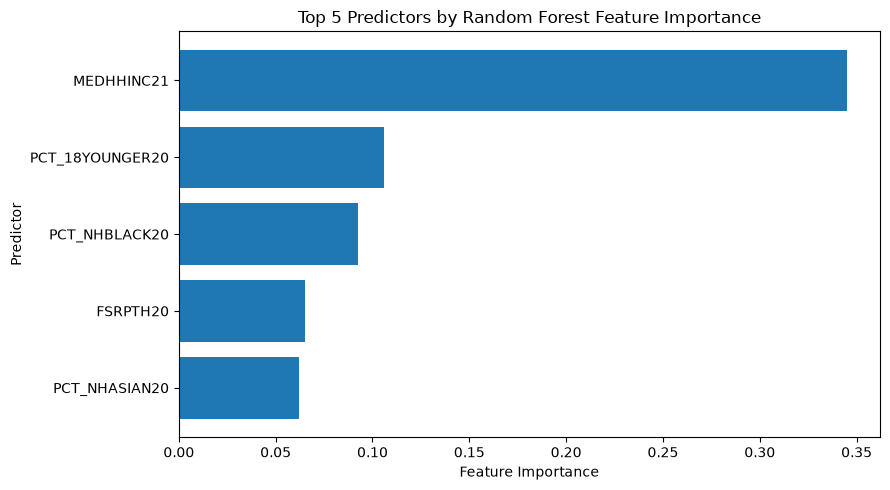

In [10]:
import matplotlib.pyplot as plt

rf_plot = rf_top5.sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 5))

plt.barh(
    rf_plot["Feature"],
    rf_plot["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("Top 5 Predictors by Random Forest Feature Importance")

plt.tight_layout()
plt.show()

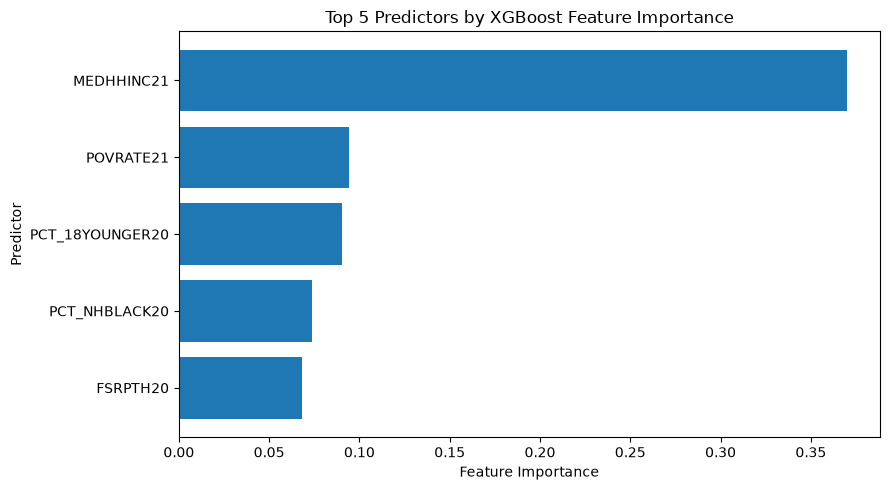

In [11]:
xgb_plot = xgb_top5.sort_values("Importance", ascending=True)

plt.figure(figsize=(9, 5))

plt.barh(
    xgb_plot["Feature"],
    xgb_plot["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("Top 5 Predictors by XGBoost Feature Importance")

plt.tight_layout()
plt.show()

In [12]:
FEATURE_OUTPUT_DIR = OUTPUTS_DIR / "feature_importance"
FEATURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# All 14 retained predictors
rf_importance_df.to_csv(
    FEATURE_OUTPUT_DIR / "rf_feature_importance.csv",
    index=False
)

xgb_importance_df.to_csv(
    FEATURE_OUTPUT_DIR / "xgb_feature_importance.csv",
    index=False
)

# Top 5 predictors
rf_top5.to_csv(
    FEATURE_OUTPUT_DIR / "rf_top5_features.csv",
    index=False
)

xgb_top5.to_csv(
    FEATURE_OUTPUT_DIR / "xgb_top5_features.csv",
    index=False
)

print("Feature importance outputs saved:")
for file in sorted(FEATURE_OUTPUT_DIR.iterdir()):
    print("-", file.name)

Feature importance outputs saved:
- .gitkeep
- rf_feature_importance.csv
- rf_top5_features.csv
- xgb_feature_importance.csv
- xgb_top5_features.csv


In [13]:
# Reload saved Top 5 files
saved_rf_top5 = pd.read_csv(
    FEATURE_OUTPUT_DIR / "rf_top5_features.csv"
)

saved_xgb_top5 = pd.read_csv(
    FEATURE_OUTPUT_DIR / "xgb_top5_features.csv"
)

print("Feature Importance Verification")
print("--------------------------------")

print("RF Top 5 rows:", len(saved_rf_top5))
print("RF duplicate features:", saved_rf_top5["Feature"].duplicated().sum())
print("RF missing importance values:", saved_rf_top5["Importance"].isna().sum())

print()

print("XGB Top 5 rows:", len(saved_xgb_top5))
print("XGB duplicate features:", saved_xgb_top5["Feature"].duplicated().sum())
print("XGB missing importance values:", saved_xgb_top5["Importance"].isna().sum())

print("\nRF importance sum (all retained predictors):",
      round(rf_importance_df["Importance"].sum(), 6))

print("XGB importance sum (all retained predictors):",
      round(xgb_importance_df["Importance"].sum(), 6))

Feature Importance Verification
--------------------------------
RF Top 5 rows: 5
RF duplicate features: 0
RF missing importance values: 0

XGB Top 5 rows: 5
XGB duplicate features: 0
XGB missing importance values: 0

RF importance sum (all retained predictors): 1.0
XGB importance sum (all retained predictors): 1.0
